# 02 Plot

Loads `../output/full_dataset.csv` and generates publication figures.

**Output:** `../output/figures/`

| Figure | Description |
|---|---|
| `fig1_pllps_distribution` | pLLPS score histogram coloured by class |
| `fig2_membrane_vs_nonmembrane` | violin + box: membrane vs non-membrane |
| `fig3_by_function` | violin with quartile markers: pLLPS by primary functional group (membrane) |
| `fig3_by_function_observations` | points + quartile box: pLLPS by primary functional group (membrane) |
| `fig4_by_location` | box: pLLPS by subcellular location, all proteins |
| `fig5_kde_distributions` | KDE: all / membrane+non-membrane / by TMD count |
| `fig6_membrane_by_function` | violin + box: membrane subset by function (all categories) |
| `fig7_membrane_by_location` | violin + box: membrane subset by location |
| `fig8_pct_above_cutoff_function` | % pLLPS > 0.6 by function, membrane subset, n= labels |
| `fig9_pct_above_cutoff_location` | % pLLPS > 0.6 by location, membrane subset, n= labels |

In [1]:
from ast import literal_eval
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "xtick.labelsize": 9, "ytick.labelsize": 9})

DATA    = Path("../output/full_dataset.csv")
FIG_DIR = Path("../output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = 0.6  # threshold for enrichment barplots

# Okabe-Ito colorblind-friendly palette
C = {
    "Membrane":     "#0072B2",
    "Non-Membrane": "#E69F00",
    "Cytosolic":    "#009E73",
    "High":         "#e74c3c",
    "Medium":       "#f39c12",
    "Low":          "#3498db",
}


def wrap_labels(values, width=18):
    return [fill(str(value), width=width) for value in values]


In [2]:
df = pd.read_csv(DATA)

# Parse list columns stored as string repr
for col in ["Location Categories", "All_Functional_Groups"]:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: literal_eval(x) if isinstance(x, str) and x.startswith("[") else []
        )

# Is_Membrane comes back as a string from CSV
if df["Is_Membrane"].dtype == object:
    df["Is_Membrane"] = df["Is_Membrane"].map({"True": True, "False": False})

print(f"{len(df):,} proteins  |  {df['pLLPS_Class'].value_counts().to_dict()}")
print(f"Membrane: {df['Is_Membrane'].sum():,}  |  TMD_count unique: {sorted(df['TMD_count'].unique())[:10]}")
df.head(2)

20,366 proteins  |  {'Low': 10797, 'High': 6568, 'Medium': 3001}
Membrane: 7,563  |  TMD_count unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,Entry,Entry name,Protein names,p(LLPS),n(DPR=> 25),Organism,Length,Function [CC],Involvement in disease,Cross-reference (PDB),...,GO_Slim_Categories,Functional Slim,Subcellular location [CC],Location Categories,Location_IDs,Location Primary,Transmembrane,Intramembrane,TMD_count,Is_Membrane
0,Q9Y6V0,PCLO_HUMAN,Protein piccolo (Aczonin),1.0,21,Homo sapiens (Human),5142.0,Scaffold protein of the presynaptic cytomatri...,Pontocerebellar hypoplasia 3 (PCH3) [MIM:6080...,1UJD;,...,"['structural molecule activity', 'cytoskeleton...",structural molecule activity,"Cell junction, synapse, presynaptic active zo...","[Cell junction, Synapse, Presynaptic active zone]","['SL-0038', 'SL-0258', 'SL-0519']",Cell junction,NaN,NaN,0,False
1,Q9Y566,SHAN1_HUMAN,SH3 and multiple ankyrin repeat domains protei...,1.0,8,Homo sapiens (Human),2161.0,Seems to be an adapter protein in the postsyn...,NaN,6CPI;,...,"['structural molecule activity', 'cytosol', 'p...",structural molecule activity,"Cytoplasm {ECO:0000250}. Cell junction, synap...","[Cytoplasm, Cell junction, Synapse, Postsynapt...","['SL-0086', 'SL-0038', 'SL-0258', 'SL-0297']",Cytoplasm,NaN,NaN,0,False


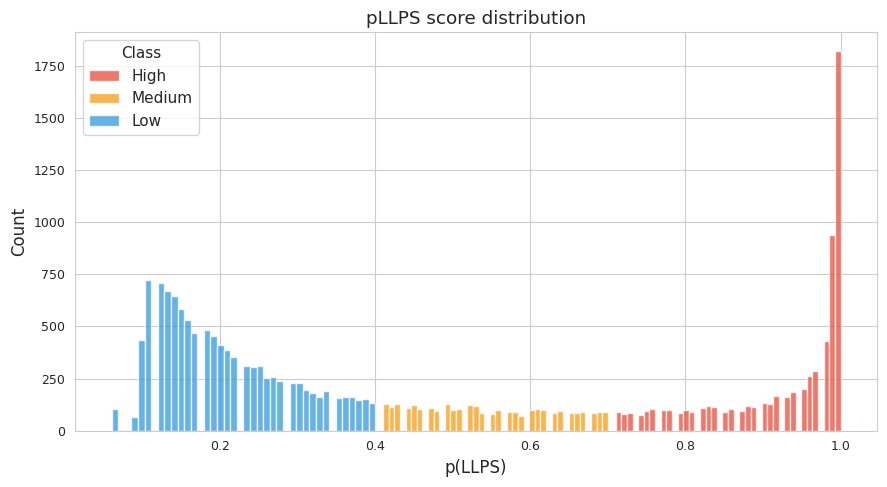

In [3]:
# Fig 1 — pLLPS score distribution
fig, ax = plt.subplots(figsize=(9, 5))
for cls in ["High", "Medium", "Low"]:
    ax.hist(df[df["pLLPS_Class"] == cls]["p(LLPS)"], bins=40, alpha=0.75,
            color=C[cls], label=cls)
ax.set(xlabel="p(LLPS)", ylabel="Count", title="pLLPS score distribution")
ax.legend(title="Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_pllps_distribution.png", dpi=300)
plt.show()

/tmp/ipykernel_167659/4025223080.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long, x="Group", y="pLLPS", inner="quartile", cut=0,
/tmp/ipykernel_167659/4025223080.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long, x="Group", y="pLLPS", width=0.4, showfliers=False,


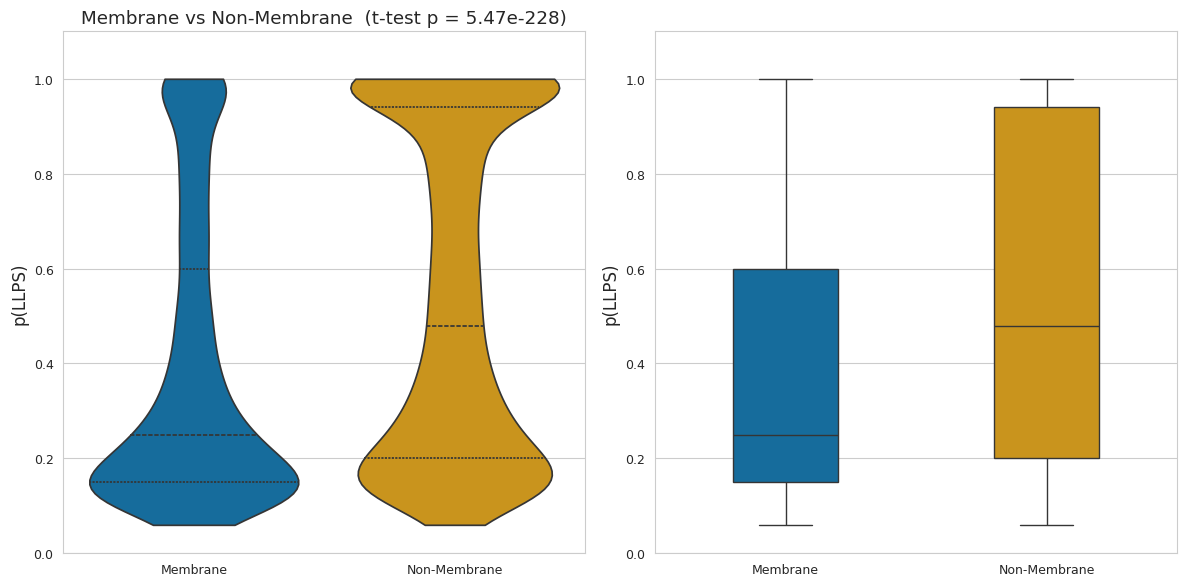

In [4]:
# Fig 2 — membrane vs non-membrane
groups = {
    "Membrane":     df[df["Is_Membrane"] == True]["p(LLPS)"].dropna(),
    "Non-Membrane": df[df["Is_Membrane"] == False]["p(LLPS)"].dropna(),
}
long = pd.concat(
    [s.rename("pLLPS").to_frame().assign(Group=k) for k, s in groups.items()]
)
_, p = stats.ttest_ind(*groups.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
palette = [C[g] for g in groups]
sns.violinplot(data=long, x="Group", y="pLLPS", inner="quartile", cut=0,
               palette=palette, ax=axes[0])
sns.boxplot(data=long, x="Group", y="pLLPS", width=0.4, showfliers=False,
            palette=palette, ax=axes[1])
for ax in axes:
    ax.set(ylim=(0, 1.1), xlabel="", ylabel="p(LLPS)")
axes[0].set_title(f"Membrane vs Non-Membrane  (t-test p = {p:.2e})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_membrane_vs_nonmembrane.png", dpi=300)
plt.show()

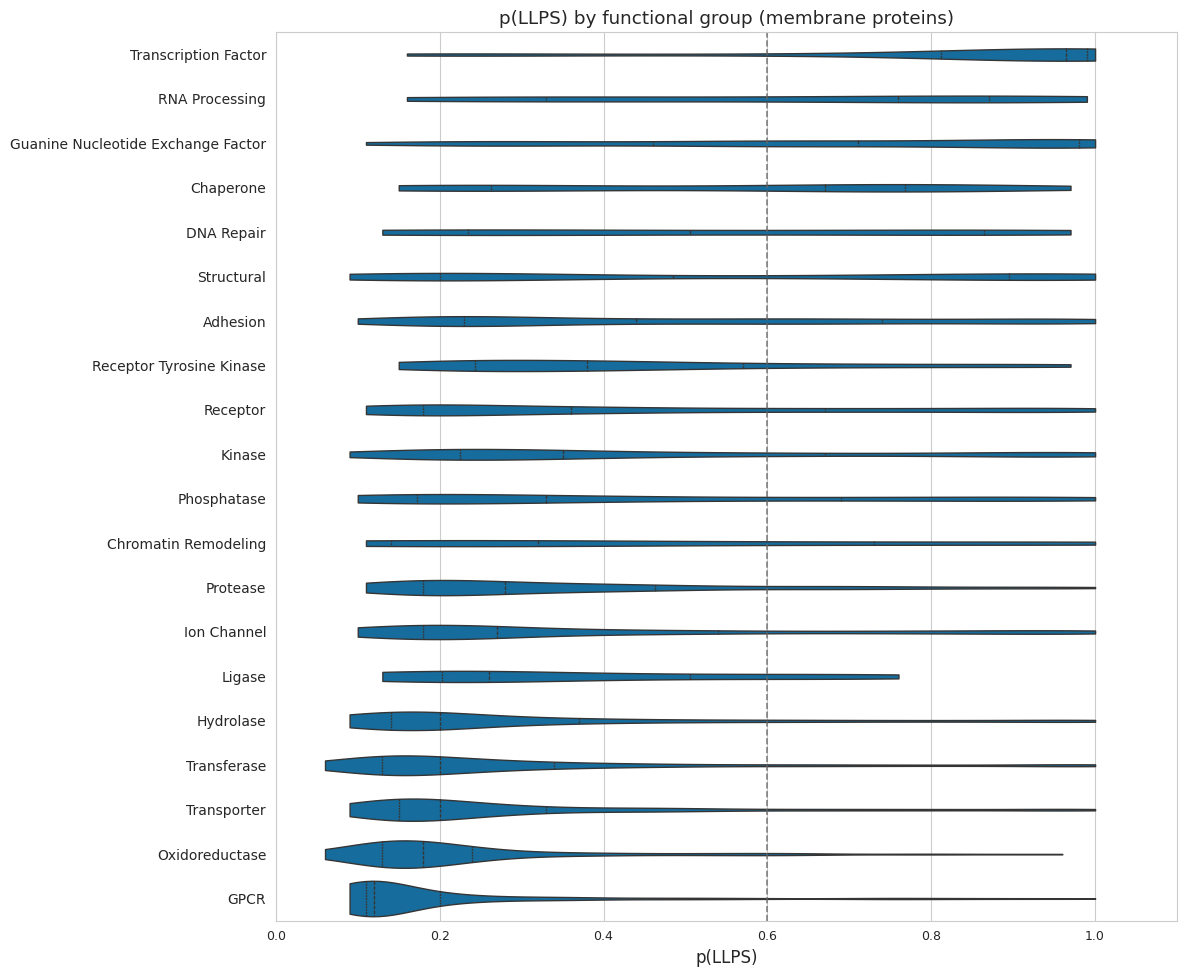

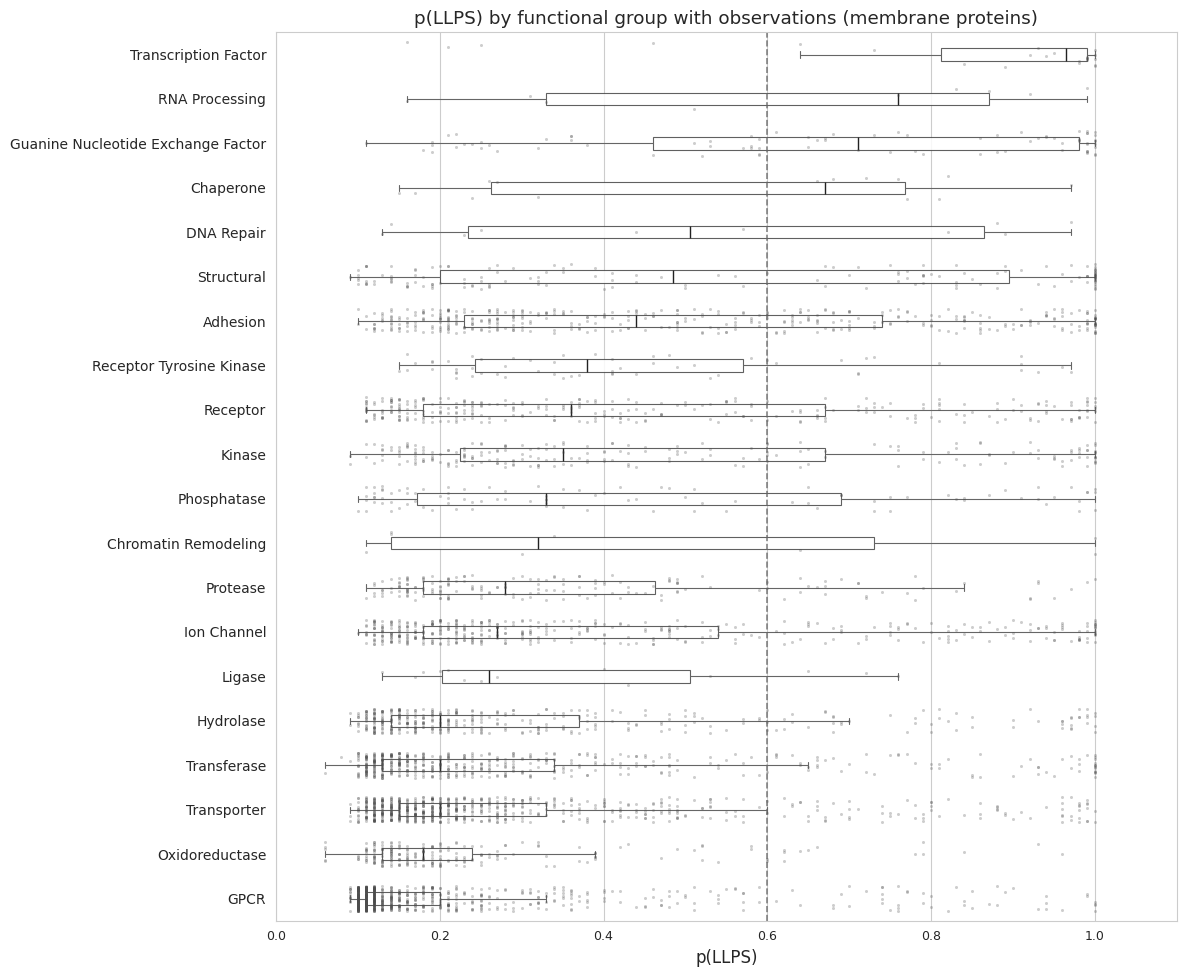

In [5]:
# Fig 3 — pLLPS by primary functional group (membrane proteins, excluding 'Other')
mem = df[df["Is_Membrane"] == True].copy()
named = mem[mem["Functional Group"] != "Other"]
order = (
    named.groupby("Functional Group")["p(LLPS)"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * len(order) + 1.5)))
sns.violinplot(
    data=named,
    y="Functional Group",
    x="p(LLPS)",
    order=order,
    inner="quartile",
    cut=0,
    color=C["Membrane"],
    linewidth=1,
    ax=ax,
)
ax.axvline(CUTOFF, color="#666666", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=10)
ax.set_title("p(LLPS) by functional group (membrane proteins)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_by_function.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * len(order) + 1.5)))
sns.stripplot(
    data=named,
    x="p(LLPS)",
    y="Functional Group",
    order=order,
    color="#4d4d4d",
    alpha=0.28,
    size=2.2,
    jitter=0.28,
    ax=ax,
)
sns.boxplot(
    data=named,
    x="p(LLPS)",
    y="Functional Group",
    order=order,
    width=0.28,
    showfliers=False,
    showmeans=False,
    boxprops={"facecolor": "white", "edgecolor": "#444444", "linewidth": 0.8, "alpha": 0.85},
    whiskerprops={"color": "#666666", "linewidth": 0.8},
    capprops={"color": "#666666", "linewidth": 0.8},
    medianprops={"color": "#222222", "linewidth": 1.0},
    ax=ax,
)
ax.axvline(CUTOFF, color="#666666", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=10)
ax.set_title("p(LLPS) by functional group with observations (membrane proteins)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_by_function_observations.png", dpi=300, bbox_inches="tight")
plt.show()

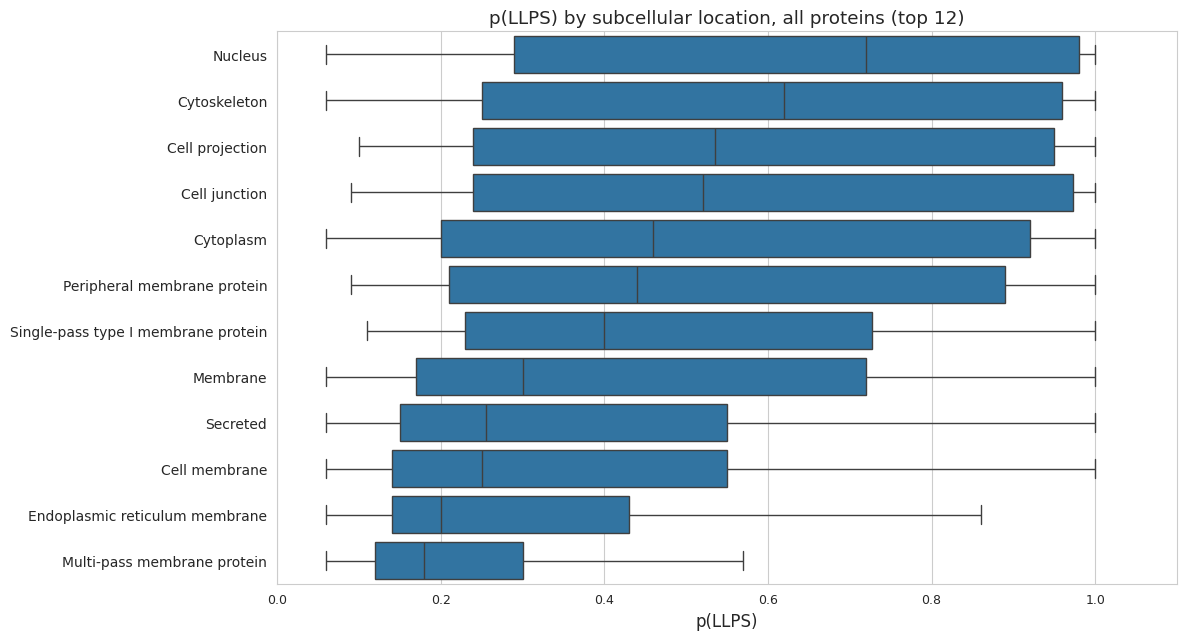

In [21]:
# Fig 4 — pLLPS by subcellular location, all proteins (top 12 by count)
loc_long = (
    df.explode("Location Categories")
    .dropna(subset=["Location Categories"])
    .query("`Location Categories` != ''")
    [["p(LLPS)", "Location Categories"]]
    .rename(columns={"Location Categories": "Location"})
)
top_locs = loc_long["Location"].value_counts().nlargest(12).index
loc_long = loc_long[loc_long["Location"].isin(top_locs)]
order_locs = (
    loc_long.groupby("Location")["p(LLPS)"]
    .median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(12, max(6, 0.42 * len(order_locs) + 1.5)))
sns.boxplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
            showfliers=False, ax=ax)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="",
       title="p(LLPS) by subcellular location, all proteins (top 12)")
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_by_location.png", dpi=300, bbox_inches="tight")
plt.show()

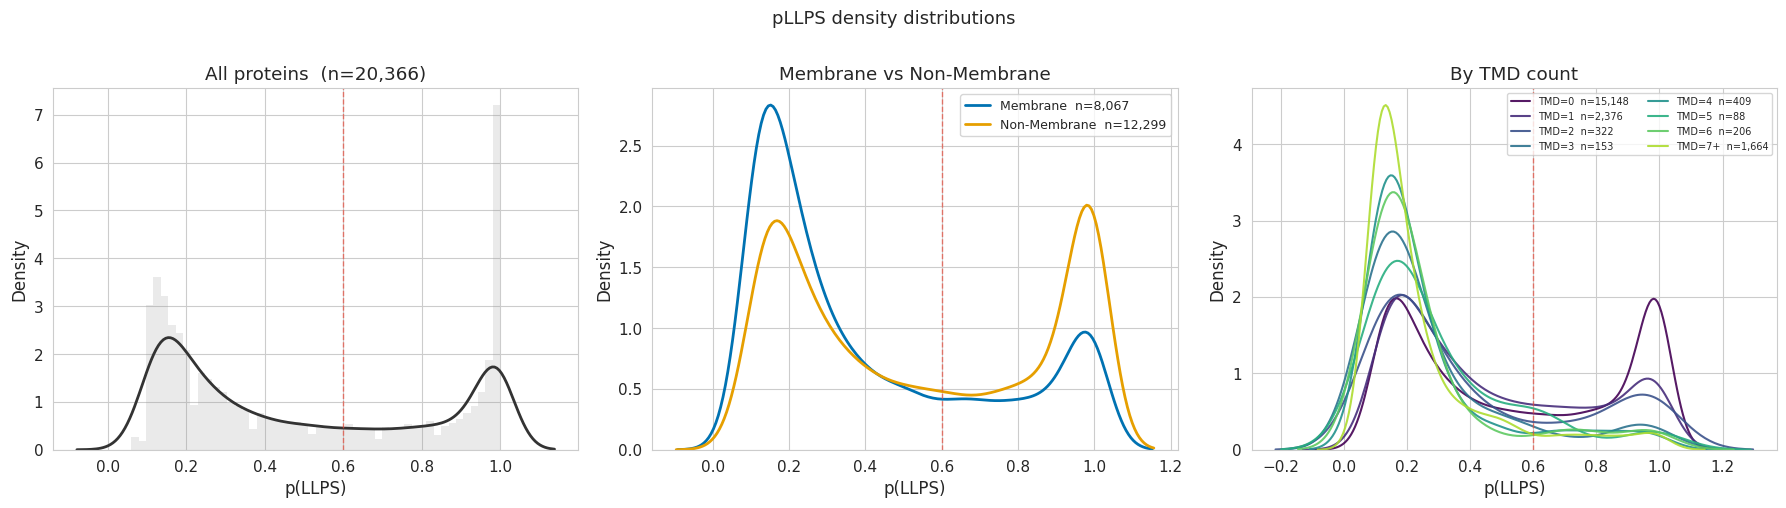

In [7]:
# Fig 5 — KDE: all proteins / membrane vs non-membrane / by TMD count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: all proteins
s_all = df["p(LLPS)"].dropna()
axes[0].hist(s_all, bins=50, density=True, alpha=0.2, color="#999999", edgecolor="none")
sns.kdeplot(s_all, ax=axes[0], color="#333333", linewidth=2)
axes[0].set(xlabel="p(LLPS)", ylabel="Density", title=f"All proteins  (n={len(s_all):,})")
axes[0].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)

# B: membrane vs non-membrane
for label, color in [("Membrane", C["Membrane"]), ("Non-Membrane", C["Non-Membrane"])]:
    s = df[df["Is_Membrane"] == (label == "Membrane")]["p(LLPS)"].dropna()
    sns.kdeplot(s, ax=axes[1], color=color, linewidth=2, label=f"{label}  n={len(s):,}")
axes[1].set(xlabel="p(LLPS)", ylabel="Density", title="Membrane vs Non-Membrane")
axes[1].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)
axes[1].legend(fontsize=9)

# C: by TMD count (0–6 individually, 7+)
cmap = plt.cm.viridis
grp_order = [str(i) for i in range(7)] + ["7+"]
df["_tmd_grp"] = df["TMD_count"].apply(lambda x: str(int(x)) if int(x) <= 6 else "7+")
plotted = 0
for i, grp in enumerate(grp_order):
    s = df[df["_tmd_grp"] == grp]["p(LLPS)"].dropna()
    if len(s) >= 20:
        sns.kdeplot(s, ax=axes[2], color=cmap(i / len(grp_order)),
                    linewidth=1.5, label=f"TMD={grp}  n={len(s):,}", alpha=0.9)
        plotted += 1
df.drop(columns=["_tmd_grp"], inplace=True)
if plotted == 0:
    axes[2].text(0.5, 0.5, "No TMD data\nRun enrich_dataset_with_tmd.py",
                 ha="center", va="center", transform=axes[2].transAxes, color="gray")
axes[2].set(xlabel="p(LLPS)", ylabel="Density", title="By TMD count")
axes[2].axvline(CUTOFF, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)
axes[2].legend(fontsize=7, ncol=2)

plt.suptitle("pLLPS density distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_kde_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

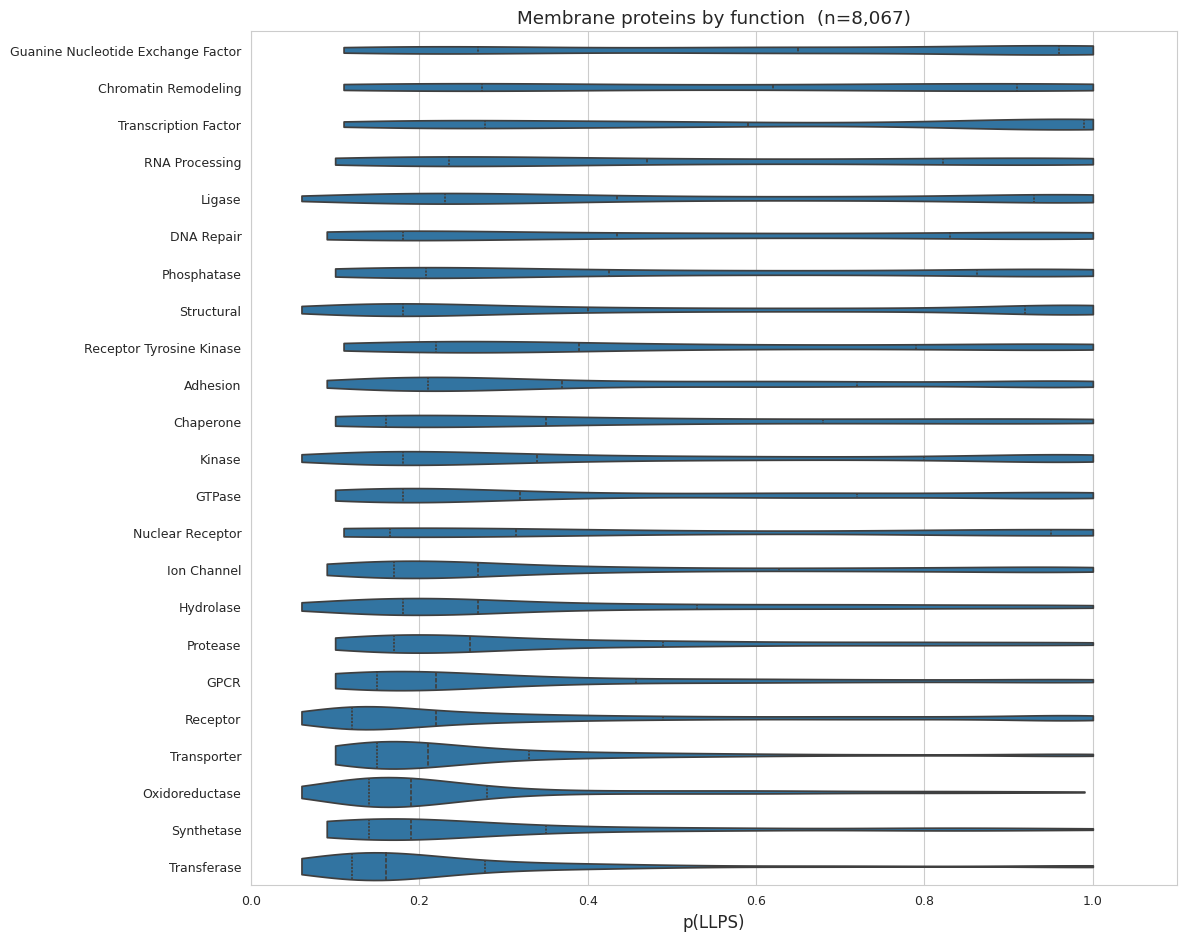

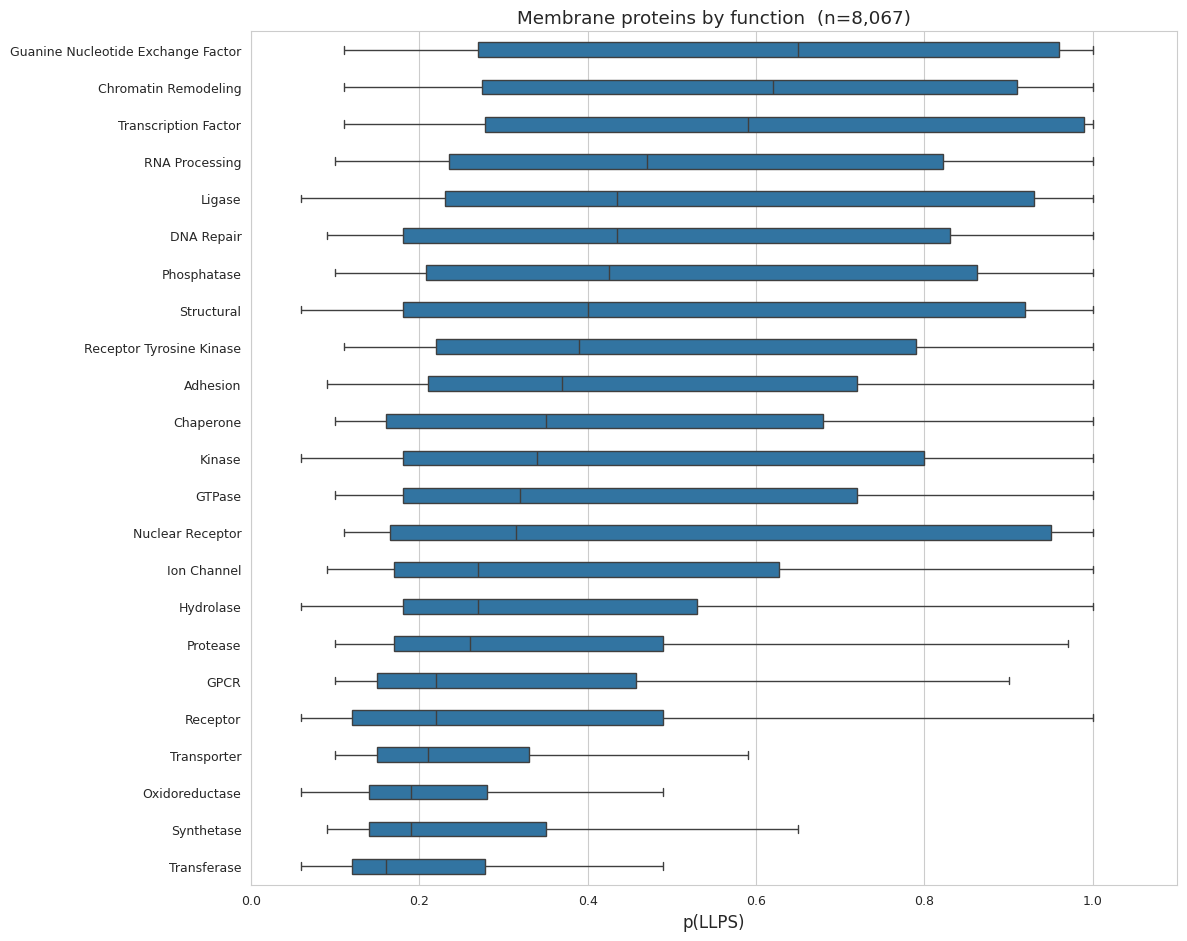

In [22]:
# Fig 6 — Membrane subset: pLLPS by function, violin + box
# Uses All_Functional_Groups (exploded) to capture all 20+ categories
mem = df[df["Is_Membrane"] == True].copy()

func_long = (
    mem.explode("All_Functional_Groups")
    .dropna(subset=["All_Functional_Groups"])
    .query("`All_Functional_Groups` != ''")
    [["p(LLPS)", "All_Functional_Groups"]]
    .rename(columns={"All_Functional_Groups": "Function"})
)
order_func = (
    func_long.groupby("Function")["p(LLPS)"]
    .median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(12, max(7, 0.35 * len(order_func) + 1.5)))
sns.violinplot(data=func_long, y="Function", x="p(LLPS)", order=order_func,
               inner="quartile", cut=0, ax=ax)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=9)
ax.set_title(f"Membrane proteins by function  (n={len(mem):,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_membrane_by_function_violin.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, max(7, 0.35 * len(order_func) + 1.5)))
sns.boxplot(data=func_long, y="Function", x="p(LLPS)", order=order_func,
            width=0.4, showfliers=False, ax=ax)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=9)
ax.set_title(f"Membrane proteins by function  (n={len(mem):,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_membrane_by_function_box.png", dpi=300, bbox_inches="tight")
plt.show()

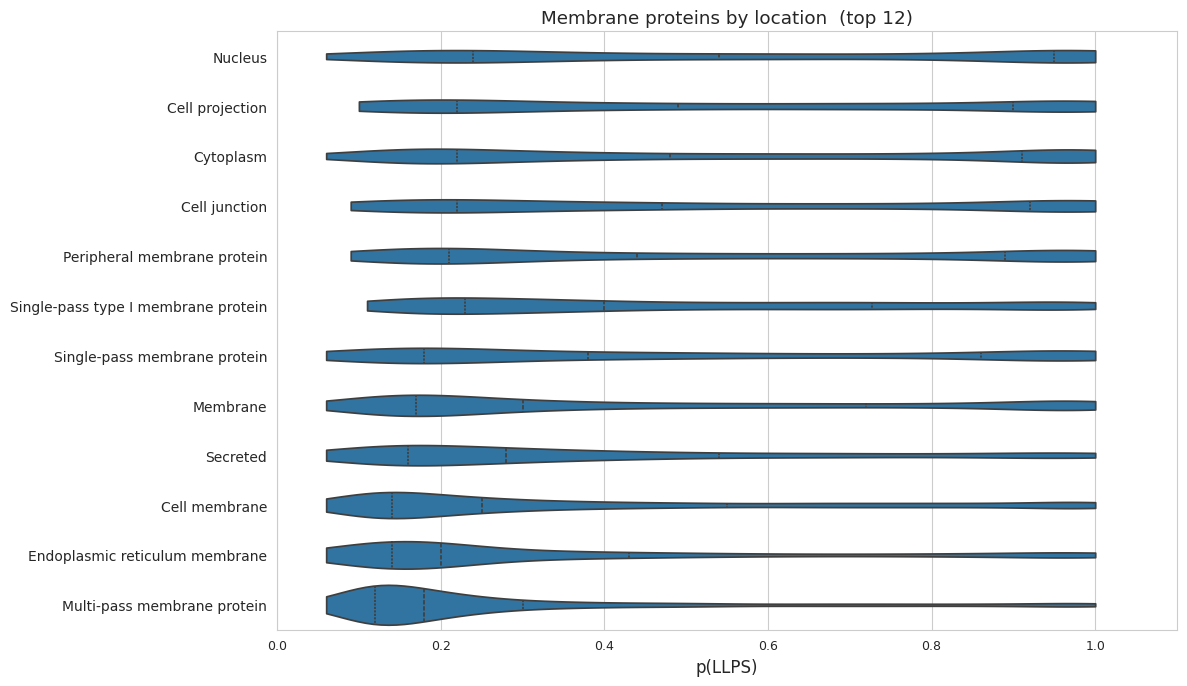

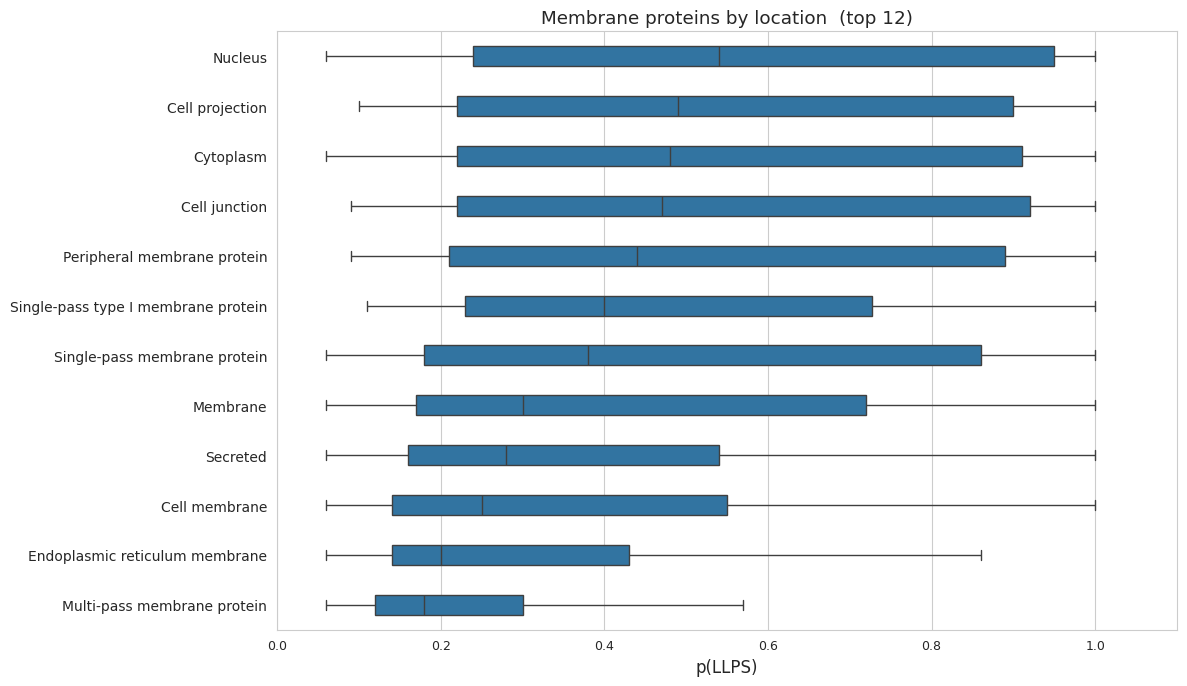

In [23]:
# Fig 7 — Membrane subset: pLLPS by location, violin + box (top 12)
loc_long = (
    mem.explode("Location Categories")
    .dropna(subset=["Location Categories"])
    .query("`Location Categories` != ''")
    [["p(LLPS)", "Location Categories"]]
    .rename(columns={"Location Categories": "Location"})
)
top_locs = loc_long["Location"].value_counts().nlargest(12).index
loc_long = loc_long[loc_long["Location"].isin(top_locs)]
order_locs = (
    loc_long.groupby("Location")["p(LLPS)"]
    .median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(12, max(7, 0.42 * len(order_locs) + 1.5)))
sns.violinplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
               inner="quartile", cut=0, ax=ax)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=10)
ax.set_title("Membrane proteins by location  (top 12)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_membrane_by_location_violin.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, max(7, 0.42 * len(order_locs) + 1.5)))
sns.boxplot(data=loc_long, y="Location", x="p(LLPS)", order=order_locs,
            width=0.4, showfliers=False, ax=ax)
ax.set(xlim=(0, 1.1), xlabel="p(LLPS)", ylabel="")
ax.tick_params(axis="y", labelsize=10)
ax.set_title("Membrane proteins by location  (top 12)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_membrane_by_location_box.png", dpi=300, bbox_inches="tight")
plt.show()

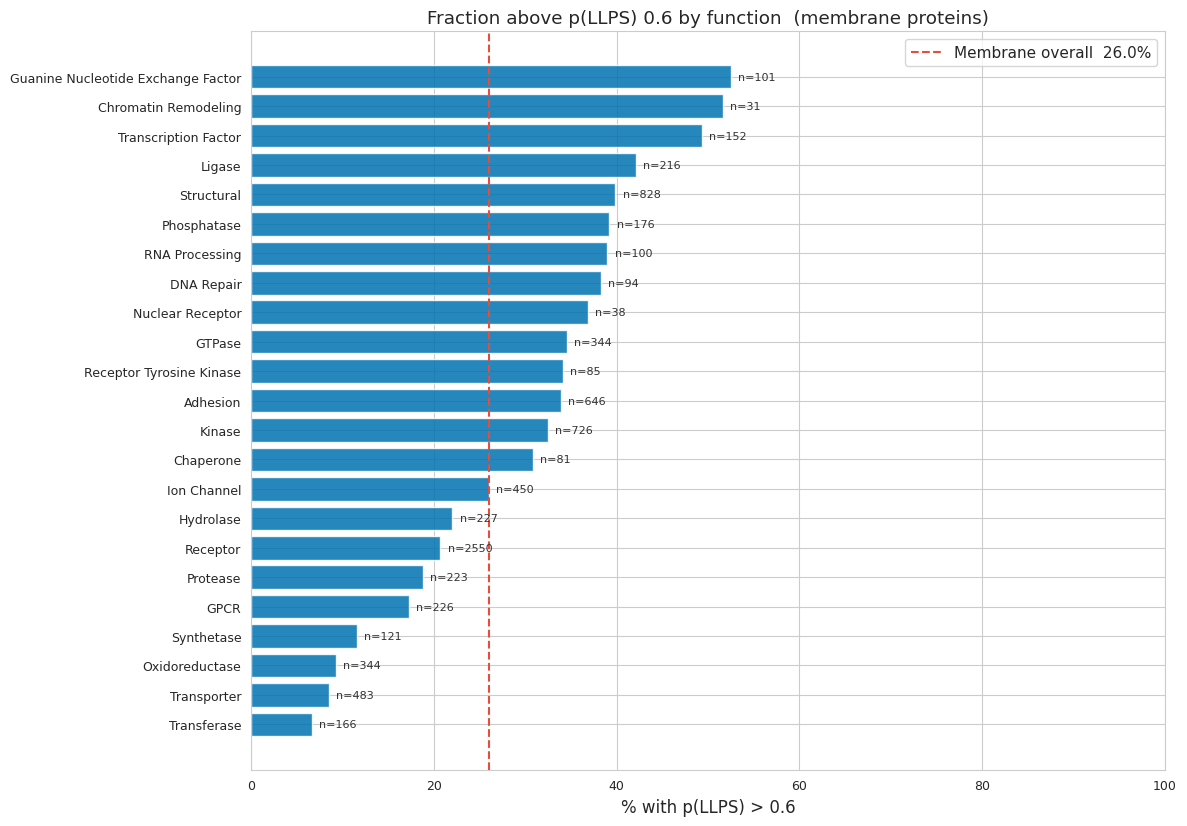

In [24]:
# Fig 8 — % above cutoff by function (membrane subset)
overall_pct = 100 * (mem["p(LLPS)"] > CUTOFF).sum() / len(mem)

func_stats = (
    mem.explode("All_Functional_Groups")
    .dropna(subset=["All_Functional_Groups"])
    .query("`All_Functional_Groups` != ''")
    .groupby("All_Functional_Groups")["p(LLPS)"]
    .agg(n="count", n_above=lambda s: (s > CUTOFF).sum())
    .reset_index()
    .rename(columns={"All_Functional_Groups": "Function"})
)
func_stats["pct"] = 100 * func_stats["n_above"] / func_stats["n"]
func_stats = func_stats.sort_values("pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(7, 0.3 * len(func_stats) + 1.5)))
ax.barh(func_stats["Function"], func_stats["pct"], color=C["Membrane"], alpha=0.85, edgecolor="white")
ax.axvline(overall_pct, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Membrane overall  {overall_pct:.1f}%")
for y, (_, row) in enumerate(func_stats.iterrows()):
    ax.text(row["pct"] + 0.8, y, f"n={int(row['n'])}", va="center", fontsize=8, color="#333333")
ax.set(xlim=(0, max(100, func_stats["pct"].max() * 1.12)), xlabel=f"% with p(LLPS) > {CUTOFF}", ylabel="",
       title=f"Fraction above p(LLPS) {CUTOFF} by function  (membrane proteins)")
ax.tick_params(axis="y", labelsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_pct_above_cutoff_function.png", dpi=300, bbox_inches="tight")
plt.show()

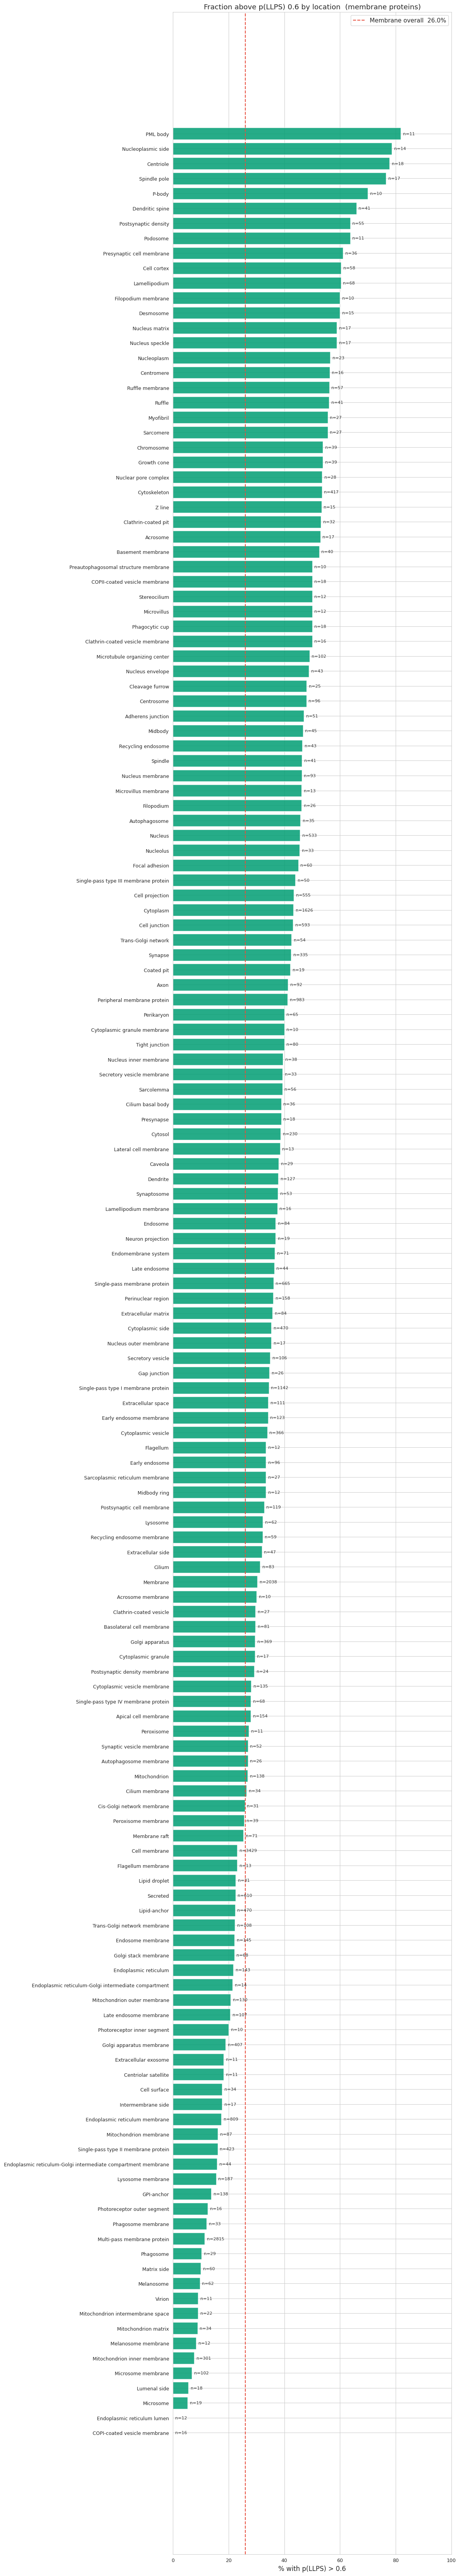

In [25]:
# Fig 9 — % above cutoff by location (membrane subset, min n=10)
loc_stats = (
    mem.explode("Location Categories")
    .dropna(subset=["Location Categories"])
    .query("`Location Categories` != ''")
    .groupby("Location Categories")["p(LLPS)"]
    .agg(n="count", n_above=lambda s: (s > CUTOFF).sum())
    .reset_index()
    .rename(columns={"Location Categories": "Location"})
)
loc_stats["pct"] = 100 * loc_stats["n_above"] / loc_stats["n"]
loc_stats = loc_stats[loc_stats["n"] >= 10].sort_values("pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, max(7, 0.42 * len(loc_stats) + 1.5)))
ax.barh(loc_stats["Location"], loc_stats["pct"], color=C["Cytosolic"], alpha=0.85, edgecolor="white")
ax.axvline(overall_pct, color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Membrane overall  {overall_pct:.1f}%")
for y, (_, row) in enumerate(loc_stats.iterrows()):
    ax.text(row["pct"] + 0.8, y, f"n={int(row['n'])}", va="center", fontsize=8, color="#333333")
ax.set(xlim=(0, max(100, loc_stats["pct"].max() * 1.12)), xlabel=f"% with p(LLPS) > {CUTOFF}", ylabel="",
       title=f"Fraction above p(LLPS) {CUTOFF} by location  (membrane proteins)")
ax.tick_params(axis="y", labelsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_pct_above_cutoff_location.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
print("Figures written to", FIG_DIR.resolve())
for f in sorted(FIG_DIR.glob("*.png")):
    print(" ", f.name)

Figures written to /workspaces/mem_prot_llps/output/figures
  fig1_pllps_distribution.png
  fig2_membrane_vs_nonmembrane.png
  fig3_by_function.png
  fig4_by_location.png
  fig5_kde_distributions.png
  fig6_membrane_by_function.png
  fig7_membrane_by_location.png
  fig8_pct_above_cutoff_function.png
  fig9_pct_above_cutoff_location.png
